In [1]:
# imports and constants

# !pip install tqdm

import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# loading image and mask

IMAGE_PATH = "../data/processed/images/ngc628Norm.npy"
MASK_PATH = "../data/processed/masks/ngc628NormMask.npy"
OUTPUT_DIR = "../data/processed/patches"
# DATA_DIR = "../data/processed"

os.makedirs(OUTPUT_DIR, exist_ok=True)

metadata_path = os.path.join(OUTPUT_DIR, "patchMetadata.csv")

PATCH_SIZE = 256
STRIDE = 128  # liitle overlap 

# THRESHOLD = 0.05
LOW_THRESHOLD = 0.001   # negative patch threshold
HIGH_THRESHOLD = 0.05   # positive patch threshold


In [3]:
# validation and normalization

image = np.load(IMAGE_PATH).astype(np.float32)
mask = np.load(MASK_PATH).astype(np.float32)

In [4]:
# small sanity check
print("Image shape:", image.shape, "dtype:", image.dtype, "min/max:", image.min(), image.max())
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "min/max:", mask.min(), mask.max())
print("Bubble pixels:", int(mask.sum()))

unique_vals = np.unique(mask)
print("Mask unique values:", unique_vals[:10])

Image shape: (1177, 2380) dtype: float32 min/max: 0.0 1.0
Mask shape: (1177, 2380) dtype: float32 min/max: 0.0 1.0
Bubble pixels: 259026
Mask unique values: [0. 1.]


In [5]:
assert image.shape == mask.shape, "Image and mask must have the same height and width."
assert image.ndim == 2, "Expected image to be a 2D array."
# assert mask.sum() > 0, "Mask contains no bubble pixels"

In [6]:
def extract_patches(
    image,
    mask,
    patch_size=256,
    stride=128,
    low_threshold=0.001,
    high_threshold=0.05
):
    H, W = image.shape

    pos_patches = []
    weak_patches = []
    neg_patches = []

    for y_start in range(
        0,
        H - patch_size + 1,
        stride
    ):
        for x_start in range(
            0,
            W - patch_size + 1,
            stride
        ):
            image_patch = image[
                y_start:y_start + patch_size,
                x_start:x_start + patch_size
            ]

            mask_patch = mask[
                y_start:y_start + patch_size,
                x_start:x_start + patch_size
            ]

            bubble_ratio = mask_patch.mean()

            patch_record = {
                "image": image_patch,
                "mask": mask_patch,
                "y_start": y_start,
                "x_start": x_start,
                "bubble_ratio": bubble_ratio,
            }

            if bubble_ratio >= high_threshold:
                patch_record["category"] = "positive"
                pos_patches.append(patch_record)

            elif bubble_ratio >= low_threshold:
                patch_record["category"] = "weak"
                weak_patches.append(patch_record)

            else:
                patch_record["category"] = "negative"
                neg_patches.append(patch_record)

    return pos_patches, weak_patches, neg_patches

In [7]:
SEED = 42
np.random.seed(SEED)

pos, weak, neg = extract_patches(image, mask, patch_size=PATCH_SIZE, stride=STRIDE, low_threshold=LOW_THRESHOLD, high_threshold=HIGH_THRESHOLD)

print(f"Positive patches: {len(pos)}")
print(f"Weak patches: {len(weak)}")
print(f"Negative patches: {len(neg)}")

Positive patches: 86
Weak patches: 25
Negative patches: 25


In [8]:
np.random.shuffle(weak)
np.random.shuffle(neg)

n_positive = len(pos)
n_weak = min(len(weak), n_positive)
n_neg = min(len(neg), n_positive // 2)

dataset = pos + weak[:n_weak] + neg[:n_neg]

np.random.shuffle(dataset)

print(f"Dataset: {len(dataset)}")

Dataset: 136


In [9]:
X = np.array(
    [record["image"] for record in dataset],
    dtype=np.float32
)

Y = np.array(
    [record["mask"] for record in dataset],
    dtype=np.float32
)

X = X[..., np.newaxis]
Y = Y[..., np.newaxis]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

assert X.shape == Y.shape
assert X.ndim == 4

X shape: (136, 256, 256, 1)
Y shape: (136, 256, 256, 1)


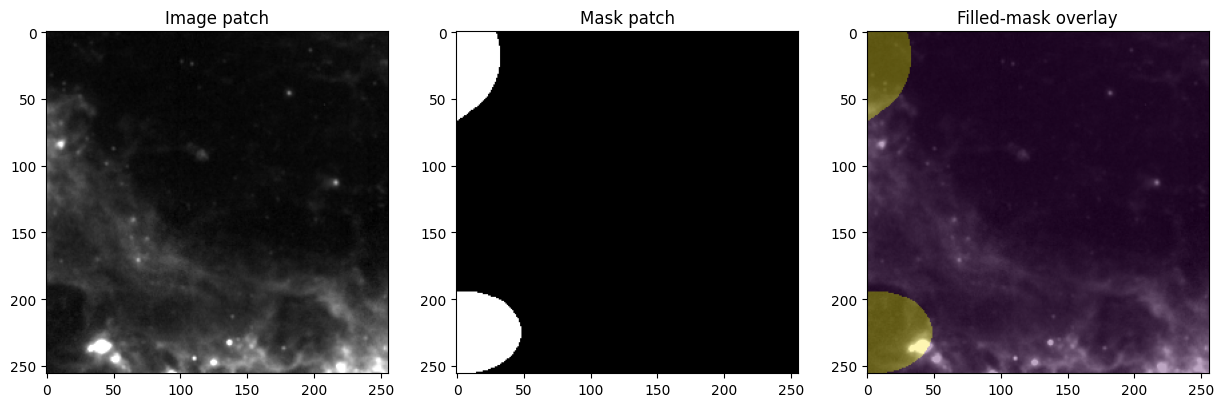

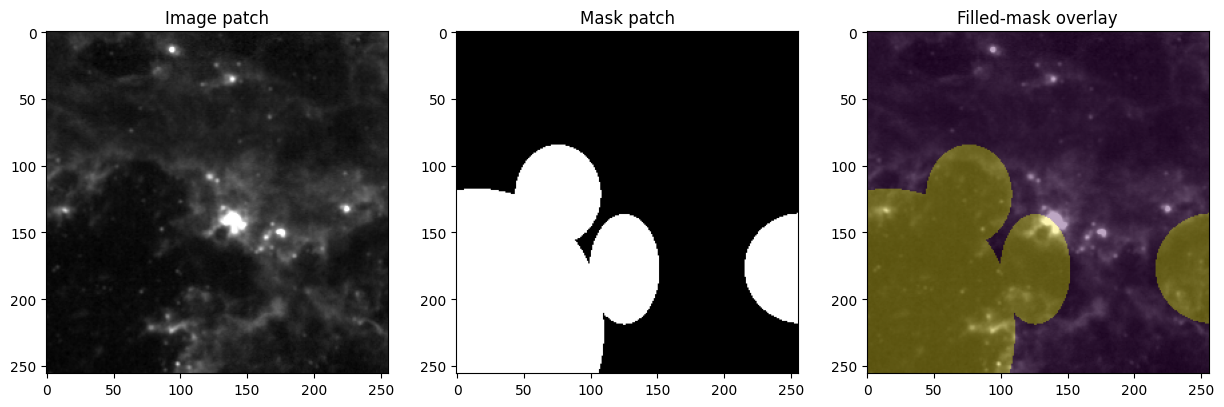

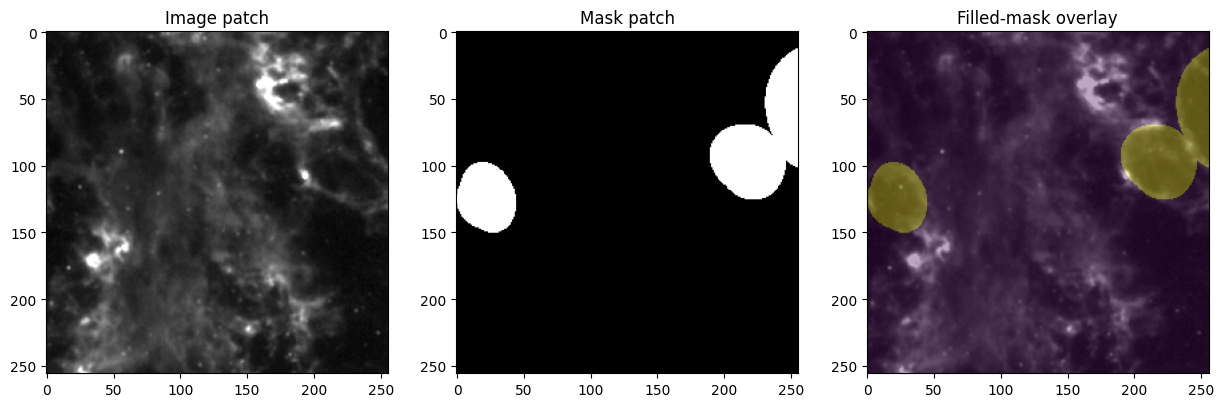

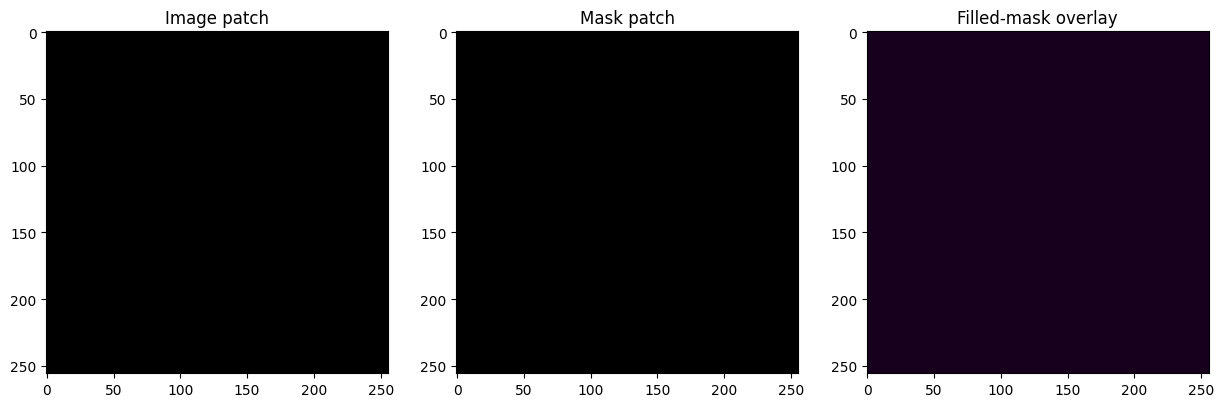

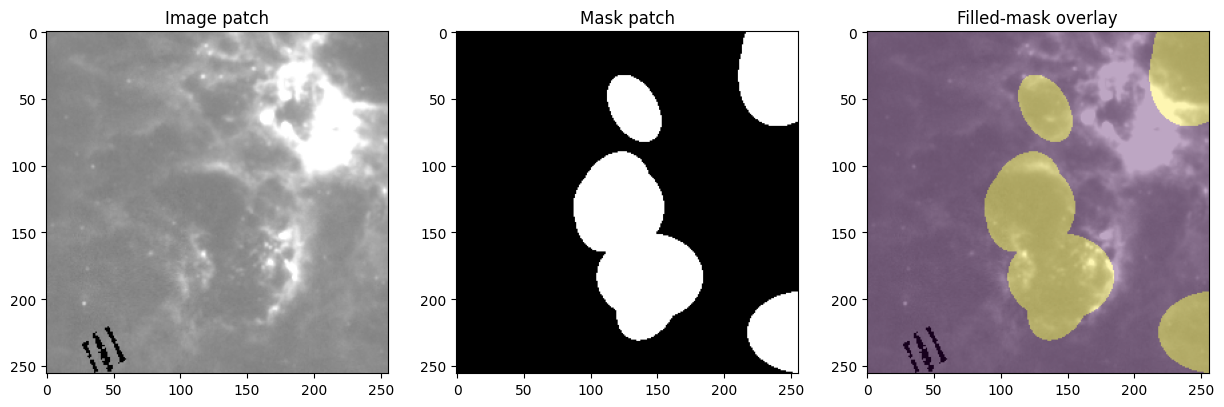

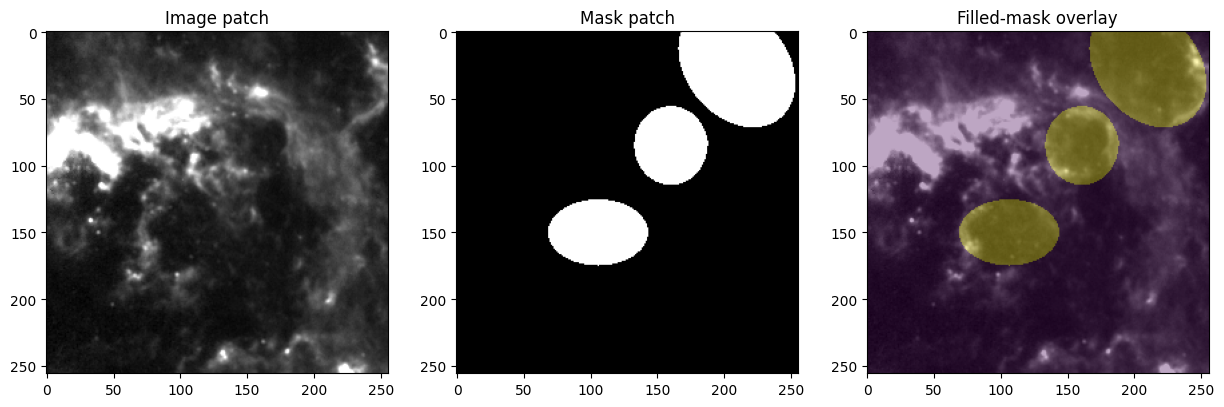

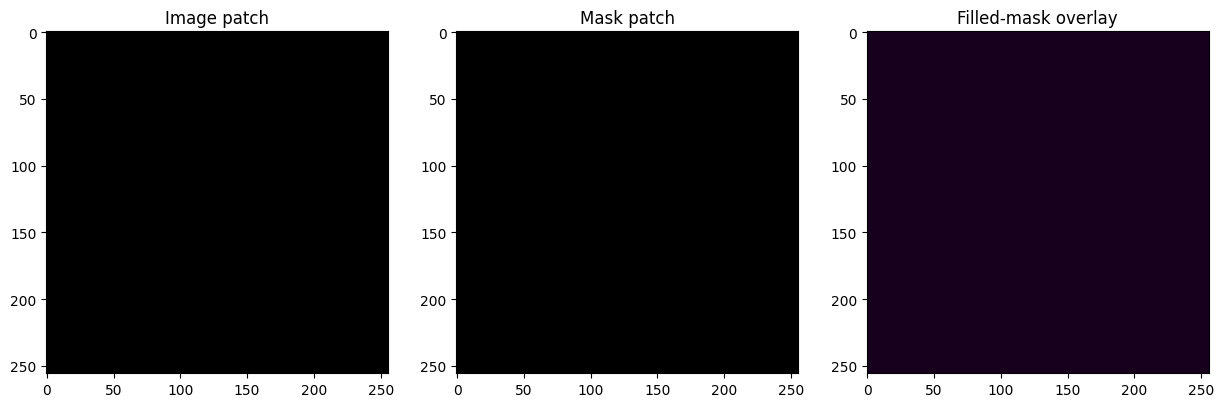

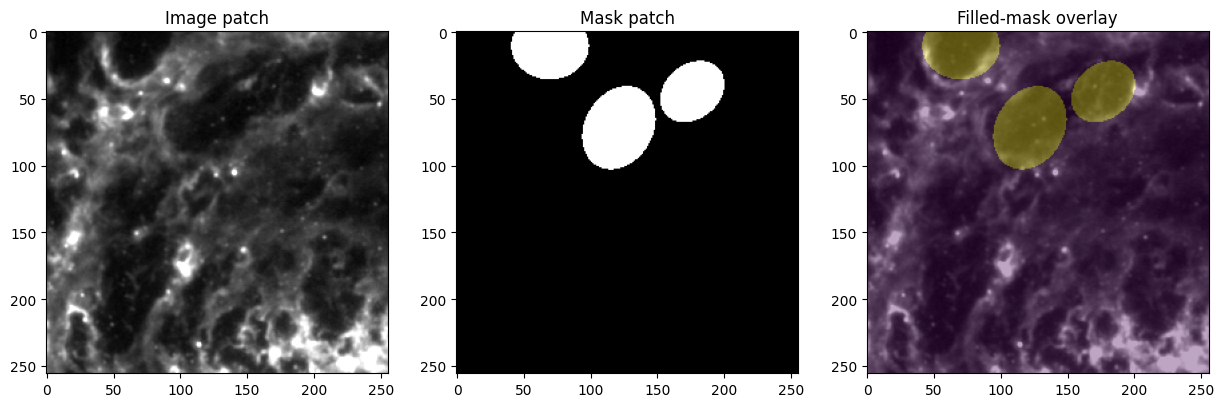

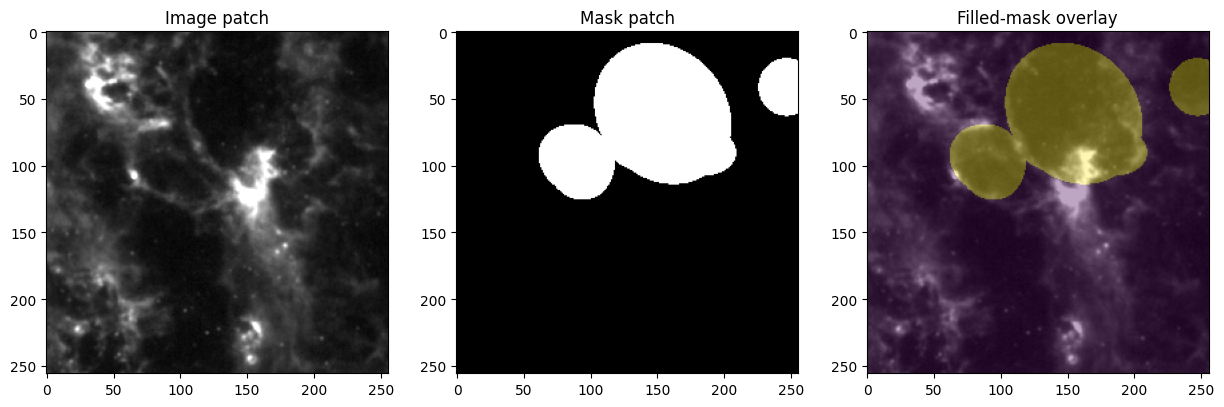

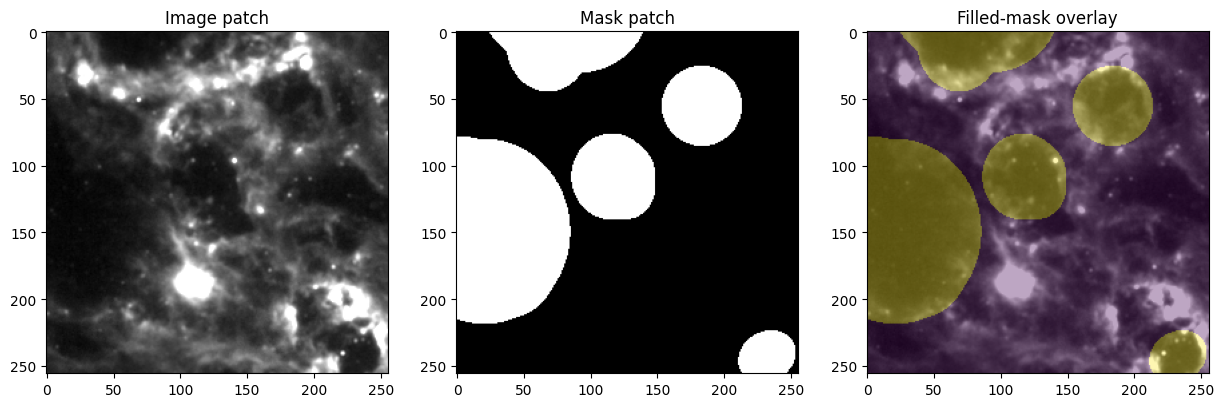

In [10]:
# sanity check

for i in range(10):

    plt.figure(figsize=(15,6))

    plt.subplot(1,3,1)
    plt.imshow(X[i].squeeze(), cmap="gray")
    plt.title("Image patch")

    plt.subplot(1,3,2)
    plt.imshow(Y[i].squeeze(), cmap="gray")
    plt.title("Mask patch")

    plt.subplot(1,3,3)
    plt.imshow(X[i].squeeze(), cmap="gray")
    plt.imshow(Y[i].squeeze(), alpha=0.35)
    plt.title("Filled-mask overlay")
    
    plt.show()


In [11]:
metadata = pd.DataFrame([
    {
        "patch_id": patch_id,
        "y_start": record["y_start"],
        "x_start": record["x_start"],
        "category": record["category"],
        "bubble_ratio": record["bubble_ratio"],
    }
    for patch_id, record in enumerate(dataset)
])

metadata.head()


,patch_id,y_start,x_start,category,bubble_ratio
0,0,896,640,positive,0.063919
1,1,128,1792,positive,0.334442
2,2,640,1664,positive,0.089752
3,3,256,0,negative,0.000000
4,4,896,384,positive,0.219574


In [12]:
assert len(metadata) == len(X), (
    f"Metadata has {len(metadata)} rows, "
    f"but X has {len(X)} patches."
)

assert np.array_equal(
    metadata["patch_id"].to_numpy(),
    np.arange(len(X))
), "Patch IDs do not correspond to the X/Y array positions."

print("Number of patches:", len(X))
print("Number of metadata rows:", len(metadata))
print("Unique patch IDs:", metadata["patch_id"].nunique())

Number of patches: 136
Number of metadata rows: 136
Unique patch IDs: 136


In [13]:
metadata.to_csv(metadata_path, index=False)

print("Saved metadata to:", metadata_path)


Saved metadata to: ../data/processed/patches/patchMetadata.csv


In [14]:
np.save(os.path.join(OUTPUT_DIR, "X.npy"), X)
np.save(os.path.join(OUTPUT_DIR, "Y.npy"), Y)

print("Saved complete patch datasets.")

Saved complete patch datasets.
